# Demonstration of theta-restriction in `mhn`

This demo illustrates the usage of the 'set_restriction' method in the Optimizer class

### Prerequisites 

This notebook assumes the usage of the local mhn-implementation (accessible via `pip install -e .`)

### Preparations
The following code largely matches the procedure presented in the normal mhn-demo `demo.ipynb`.
For simplicity's sake we don't make use of cross-validation here.

(<matplotlib.image.AxesImage at 0x1e3c7622050>,
 <matplotlib.image.AxesImage at 0x1e3da577e90>)

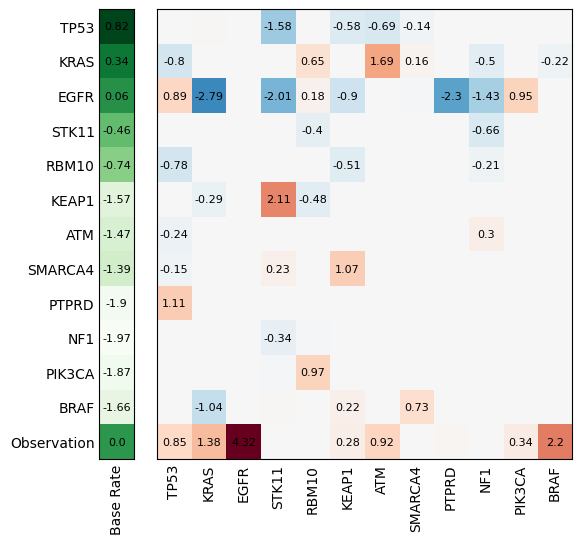

In [ ]:
# preparations as in 'demo.ipynb' (excluding cross-validation)

import mhn
from mhn.optimizers import Optimizer
import pandas as pd
import random
import numpy as np
input = pd.read_csv('LUAD_n12.csv')
n=len(input.columns)

input_subset = input.sample(n=500, random_state=6)
opt = Optimizer()
opt.load_data_matrix(input_subset)
opt.set_penalty(opt.Penalty.L1)

lambda_min = 0.1/len(input_subset)
lambda_max = 100/len(input_subset)

np.random.seed(123)
opt_lam, lambda_scores = opt.lambda_from_cv(
    lambda_min=lambda_min, lambda_max=lambda_max, steps=5, nfolds=3, show_progressbar=True, return_lambda_scores=True)

opt.train(lam=opt_lam)
opt.result.plot(colorbar=False)



## Restricting theta during training

Using the `set_restriction` method requires you to specify a restriction mask consisting of 0s and 1s. This is a matrix matching the shape of theta. 

 1 means this entry will be subject to changes during training (normal behavior)
 
 0 means this entry will remain unaltered during training

In [ ]:
restriction_mask=np.ones((n+1,n))   #as we are using oMHN by default, the matrix shape needs to be ((n+1)xn)
restriction_mask[:,4:8]=0

np.fill_diagonal(restriction_mask,1)    #make sure diagonal entries (=baserates) are not getting restricted
restriction_mask[-1]=1                #make sure bottom row (=observation rates) are not getting restricted
opt.set_restriction(restriction_mask=restriction_mask)

print(restriction_mask)

[[1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


After setting a restriction the training procedure can be continued as usual..
To indicate the restricted theta entries in the resulting MHN's plot you may use the `overlay_restriction_mask` argument of the `plot` method.

(<matplotlib.image.AxesImage at 0x1e3dac15f50>,
 <matplotlib.image.AxesImage at 0x1e3dac23950>)

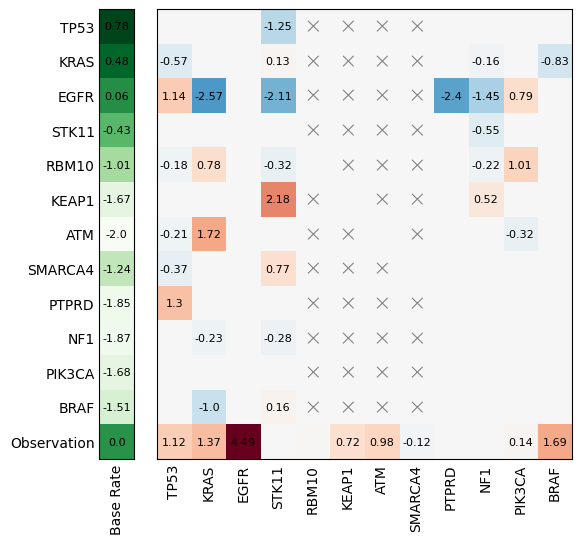

In [ ]:
opt.train(lam=opt_lam)
opt.result.save("test_save.csv")
opt.result.plot(overlay_restriction_mask=True, colorbar=False)

## Restrictions for non-default init_theta
You are able to restrict log-theta entries to take on arbitrary values by setting `init_theta`. In the following we show an example of forcing 'ATM' to have a strong negative effect on 'EGFR'. 

(<matplotlib.image.AxesImage at 0x1e3dce25c90>,
 <matplotlib.image.AxesImage at 0x1e3dac31590>)

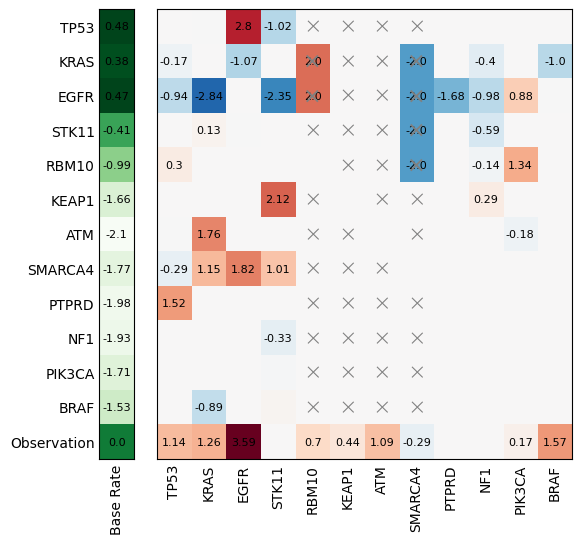

In [ ]:
#preparations
opt2 = Optimizer()
opt2.load_data_matrix(input_subset)
opt2.set_penalty(opt2.Penalty.L1)

#setting init_theta
init_theta=opt2.get_default_init_theta()

init_theta[1:3,4]=0.5              
init_theta[1:5,7]=-0.5    
opt2.set_init_theta(init_theta)

#setting restriction
opt2.set_restriction(restriction_mask)

#training
np.random.seed(123)
opt_lam2, lambda_scores2 = opt2.lambda_from_cv(
    lambda_min=lambda_min, lambda_max=lambda_max, steps=5, nfolds=3, show_progressbar=True, return_lambda_scores=True)

opt2.train(opt_lam2)

#results
opt2.result.save("test2_save.csv")
opt2.result.plot(colorbar=False)
